# Tech Challenge — Fase 4
## Etapa 1: Coleta e Pré-processamento dos Dados

Este notebook cobre o **ponto 1** do desafio: coletar preços históricos de ações
via `yfinance` e preparar os dados para alimentar uma rede neural **LSTM**.

Fluxo:
1. Coleta dos dados (Yahoo Finance)
2. Inspeção e limpeza
3. Análise exploratória rápida
4. Seleção da feature alvo (`Close`)
5. Split treino/validação respeitando a ordem temporal
6. Escalonamento (MinMaxScaler)
7. Criação das janelas temporais (sequências) para a LSTM
8. Salvamento dos artefatos (arrays + scaler)


## 0. Instalação e imports

Caso esteja rodando localmente ou no Colab, descomente a linha de instalação.

In [1]:
# !pip install yfinance scikit-learn pandas numpy matplotlib joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

import yfinance as yf

# Reprodutibilidade
np.random.seed(42)

# Pasta para salvar os artefatos da etapa
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Setup OK")

Setup OK


## 1. Coleta dos Dados

Defina o símbolo da empresa e o intervalo de datas. Aqui usamos a **Apple (AAPL)**
como exemplo — troque por qualquer ticker (ex: `DIS`, `MSFT`, `PETR4.SA` para a B3).

In [8]:
SYMBOL = "AAPL"
START_DATE = "2018-01-01"
END_DATE = "2026-06-20"

df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, auto_adjust=True)

# yfinance pode retornar colunas em MultiIndex quando há 1+ tickers.
# Achatamos para um índice simples de colunas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Linhas baixadas: {len(df)}")
df.head()

[*********************100%***********************]  1 of 1 completed

Linhas baixadas: 2127


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267071,40.276423,39.565798,39.776182,102223600
2018-01-03,40.260056,40.802375,40.196944,40.330184,118071600
2018-01-04,40.447063,40.549917,40.224995,40.332521,89738400
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
2018-01-08,40.755642,41.050175,40.657461,40.755642,82271200


## 2. Inspeção e Limpeza

Verificamos tipos, valores ausentes e a continuidade temporal.

In [9]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2127 entries, 2018-01-02 to 2026-06-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2127 non-null   float64
 1   High    2127 non-null   float64
 2   Low     2127 non-null   float64
 3   Open    2127 non-null   float64
 4   Volume  2127 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 99.7 KB


In [10]:
# Valores ausentes por coluna
print("Valores ausentes:")
print(df.isna().sum())

# Datas duplicadas?
print("\nDatas duplicadas:", df.index.duplicated().sum())

Valores ausentes:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Datas duplicadas: 0


In [11]:
# Pregões não têm fins de semana/feriados, então gaps de calendário são esperados.
# Tratamos apenas NaNs internos (ex: dados faltantes pontuais) com forward fill.
df = df.sort_index()
df = df.ffill().dropna()

print("Após limpeza:", df.shape)
print("Período:", df.index.min().date(), "->", df.index.max().date())

Após limpeza: (2127, 5)
Período: 2018-01-02 -> 2026-06-18


## 3. Análise Exploratória Rápida

Visualizamos a série do preço de fechamento — é o que vamos prever.

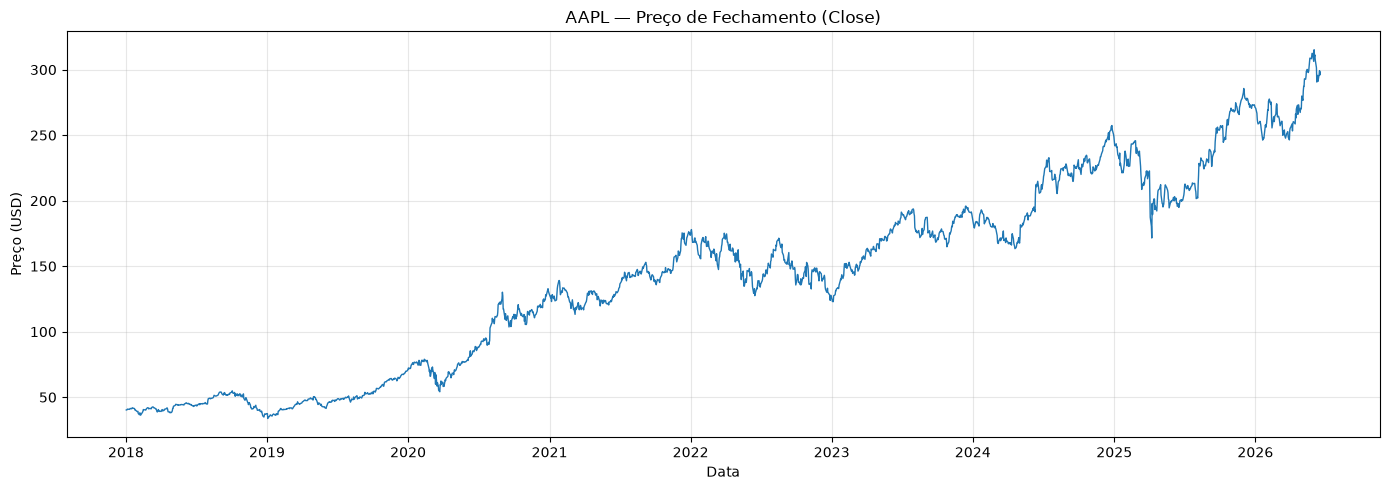

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], linewidth=1)
plt.title(f"{SYMBOL} — Preço de Fechamento (Close)")
plt.xlabel("Data")
plt.ylabel("Preço (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Estatísticas descritivas do alvo
df["Close"].describe()

count    2127.000000
mean      142.729557
std        72.052981
min        33.737000
25%        68.428799
50%       145.638229
75%       191.271698
max       315.200012
Name: Close, dtype: float64

## 4. Seleção da Feature Alvo

Para um primeiro modelo LSTM univariado, usamos apenas o **Close**.
(O array fica em formato 2D `(n_amostras, 1)` para o scaler.)

In [15]:
close_prices = df[["Close"]].copy()
print("Shape da série alvo:", close_prices.shape)
close_prices.tail()

Shape da série alvo: (2127, 1)


Price,Close
Date,
2026-06-12,291.130005
2026-06-15,296.420013
2026-06-16,299.239990
2026-06-17,295.950012
2026-06-18,298.010010


## 5. Split Treino / Validação (temporal)

**Importante:** em séries temporais **não** se embaralha os dados. O conjunto de
validação deve vir *depois* do de treino no tempo. Usamos 80% / 20%.

In [16]:
TRAIN_RATIO = 0.80
split_idx = int(len(close_prices) * TRAIN_RATIO)

train_data = close_prices.iloc[:split_idx]
valid_data = close_prices.iloc[split_idx:]

print(f"Treino:    {len(train_data)} amostras "
      f"({train_data.index.min().date()} -> {train_data.index.max().date()})")
print(f"Validação: {len(valid_data)} amostras "
      f"({valid_data.index.min().date()} -> {valid_data.index.max().date()})")

Treino:    1701 amostras (2018-01-02 -> 2024-10-04)
Validação: 426 amostras (2024-10-07 -> 2026-06-18)


## 6. Escalonamento (MinMaxScaler)

Redes LSTM convergem melhor com dados em escala pequena (0 a 1).

**Cuidado com data leakage:** o scaler é ajustado (`fit`) **apenas no treino**
e depois apenas aplicado (`transform`) na validação.

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)   # fit só no treino
valid_scaled = scaler.transform(valid_data)       # transform na validação

print("Treino escalonado -> min:", train_scaled.min(), "max:", train_scaled.max())
print("Valid. escalonado -> min:", round(valid_scaled.min(), 4),
      "max:", round(valid_scaled.max(), 4))

Treino escalonado -> min: 0.0 max: 1.0000000000000002
Valid. escalonado -> min: 0.6921 max: 1.4139


## 7. Criação das Janelas Temporais

A LSTM aprende a partir de **sequências**. Para prever o dia `t`, usamos os
`WINDOW_SIZE` dias anteriores.

- `X`: blocos de `WINDOW_SIZE` preços consecutivos -> shape `(amostras, janela, 1)`
- `y`: o preço do dia seguinte a cada bloco

Para a validação, prefixamos os últimos `WINDOW_SIZE` dias do treino, de modo que
as primeiras previsões de validação tenham histórico suficiente.

In [18]:
WINDOW_SIZE = 60  # nº de dias usados para prever o próximo

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    X = np.array(X)
    y = np.array(y)
    # LSTM espera entrada 3D: (amostras, timesteps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

# Treino
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

# Validação: anexa os últimos WINDOW_SIZE dias do treino para dar contexto
valid_input = np.concatenate([train_scaled[-WINDOW_SIZE:], valid_scaled], axis=0)
X_valid, y_valid = create_sequences(valid_input, WINDOW_SIZE)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)

X_train: (1641, 60, 1) | y_train: (1641,)
X_valid: (426, 60, 1) | y_valid: (426,)


## 8. Salvamento dos Artefatos

Guardamos os arrays prontos e o **scaler** (essencial: a API precisará dele para
escalonar a entrada e reverter a previsão para a escala de preço real).

In [19]:
np.save(os.path.join(ARTIFACTS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(ARTIFACTS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(ARTIFACTS_DIR, "X_valid.npy"), X_valid)
np.save(os.path.join(ARTIFACTS_DIR, "y_valid.npy"), y_valid)

joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "scaler.pkl"))

# Salva também o dataframe limpo para referência/reuso
df.to_csv(os.path.join(ARTIFACTS_DIR, f"{SYMBOL}_clean.csv"))

# Metadados úteis para as próximas etapas
meta = {
    "symbol": SYMBOL,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "window_size": WINDOW_SIZE,
    "train_ratio": TRAIN_RATIO,
    "feature": "Close",
}
joblib.dump(meta, os.path.join(ARTIFACTS_DIR, "meta.pkl"))

print("Artefatos salvos em:", os.path.abspath(ARTIFACTS_DIR))
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    print(" -", f)

Artefatos salvos em: /home/doglas/Documents/FIAP/TECH-CHALLENGE/artifacts
 - AAPL_clean.csv
 - X_train.npy
 - X_valid.npy
 - meta.pkl
 - scaler.pkl
 - y_train.npy
 - y_valid.npy


## Pronto ✅

A etapa 1 está completa. Os artefatos gerados (`X_train`, `y_train`, `X_valid`,
`y_valid`, `scaler.pkl`, `meta.pkl`) alimentam diretamente a **etapa 2**
(construção e treino do modelo LSTM).

**Próximos passos sugeridos:**
- Etapa 2: montar a arquitetura LSTM no Keras/TensorFlow, treinar e avaliar (MAE, RMSE, MAPE)
- Etapa 3: salvar o modelo treinado (`.keras`)
- Etapa 4: servir via FastAPI/Flask
